# Supervised Modeling

This notebook moves the project from descriptive analysis and unsupervised alert scoring into direct fraud prediction.

The earlier phases established the business context and built a feature table designed to respect time ordering. That matters because fraud modeling is not only about predictive performance. It is also about realism. A model that relies on future information or on poorly controlled sampling can appear strong on paper while being much weaker in a true monitoring environment.

For that reason, this notebook uses a time-based split and a reusable modeling pipeline. The objective is to test whether the engineered transaction-history features help a supervised model detect fraud more effectively than raw transaction fields alone.


## 1. Preparing the notebook environment

This setup cell imports the libraries needed for the modeling phase, configures dataframe display, and ensures that the project root is available on the import path.

Keeping this setup explicit makes the notebook easier to rerun and keeps it aligned with the reusable source-code modules added to the project.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## 2. Defining the feature input and modeling output paths

This notebook uses the engineered feature parquet file as its main input and writes reusable model outputs to a dedicated Phase 6 directory.

Separating modeling artifacts into their own folder helps preserve a clean handoff structure. It also makes it easy for later business-summary or presentation work to reference the exact tables created in this phase.


In [2]:
FEATURES_PATH = PROJECT_ROOT / "data" / "processed" / "model_features.parquet"
OUTPUT_DIR = PROJECT_ROOT / "data" / "outputs" / "phase_6_modeling"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Feature dataset exists:", FEATURES_PATH.exists())
print("Model output directory:", OUTPUT_DIR)


Feature dataset exists: True
Model output directory: /Users/twon/Documents/Time Series Analysis Project/data/outputs/phase_6_modeling


## 3. Importing the reusable modeling functions

The project keeps the modeling logic in `src.modeling` so that this notebook can focus on the analytical story rather than on long implementation blocks.

This is consistent with the hybrid project design described in the handoff notes: the codebase stays modular and scalable, while the notebook remains readable and presentation-ready.


In [3]:
from src.feature_engineering import build_model_features
from src.modeling import (
    get_model_feature_columns,
    run_modeling_pipeline,
    time_based_split,
)


## 4. Loading the engineered transaction dataset

The notebook first tries to load the feature table created in the prior phase. If the parquet file is missing, it rebuilds the feature dataset directly from the raw CSV so that the modeling workflow remains reproducible.

This fallback keeps the project self-contained and reduces friction when the notebook is opened in a fresh environment.


In [4]:
if FEATURES_PATH.exists():
    df = pd.read_parquet(FEATURES_PATH)
else:
    raw_path = PROJECT_ROOT / "data" / "raw" / "paysim dataset.csv"
    df = build_model_features(pd.read_csv(raw_path))

print("Modeling dataset shape:", df.shape)
df.head()


Modeling dataset shape: (6362620, 38)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,row_id,hour,day,is_transfer,is_cash_out,orig_txn_count_prior,orig_amount_prior_sum,orig_avg_amount_prior,orig_prev_step,orig_time_since_prev,orig_prev_amount,orig_amount_to_oldbalance_ratio,orig_balance_drop,orig_balance_drop_ratio,orig_amount_vs_prior_avg,dest_txn_count_prior,dest_amount_prior_sum,dest_avg_amount_prior,dest_prev_step,dest_time_since_prev,amount_vs_dest_prior_avg,orig_txn_count_last_1,orig_amount_sum_last_1,orig_txn_count_last_6,orig_amount_sum_last_6,orig_txn_count_last_24,orig_amount_sum_last_24
0,1,PAYMENT,"9,839.6400",C1231006815,"170,136.0000","160,296.3600",M1979787155,0.0000,0.0000,0,0,0,1,0,0,0,0,0.0000,NaN,NaN,NaN,NaN,0.0578,"9,839.6400",0.0578,NaN,0,0.0000,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,1,PAYMENT,"1,864.2800",C1666544295,"21,249.0000","19,384.7200",M2044282225,0.0000,0.0000,0,0,1,1,0,0,0,0,0.0000,NaN,NaN,NaN,NaN,0.0877,"1,864.2800",0.0877,NaN,0,0.0000,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,1,TRANSFER,181.0000,C1305486145,181.0000,0.0000,C553264065,0.0000,0.0000,1,0,2,1,0,1,0,0,0.0000,NaN,NaN,NaN,NaN,1.0000,181.0000,1.0000,NaN,0,0.0000,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,1,CASH_OUT,181.0000,C840083671,181.0000,0.0000,C38997010,"21,182.0000",0.0000,1,0,3,1,0,0,1,0,0.0000,NaN,NaN,NaN,NaN,1.0000,181.0000,1.0000,NaN,0,0.0000,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
4,1,PAYMENT,"11,668.1400",C2048537720,"41,554.0000","29,885.8600",M1230701703,0.0000,0.0000,0,0,4,1,0,0,0,0,0.0000,NaN,NaN,NaN,NaN,0.2808,"11,668.1400",0.2808,NaN,0,0.0000,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


## 5. Reviewing the candidate modeling feature set

This step retrieves the feature columns that are available in the current dataset and counts how many engineered predictors will be used in the supervised model.

The purpose is both practical and analytical. Practically, it confirms that the feature dataset was built correctly. Analytically, it shows how the project has moved beyond the raw transaction fields into behavioral and history-aware predictors.


In [5]:
model_feature_columns = get_model_feature_columns(df)

print("Number of modeling features:", len(model_feature_columns))
model_feature_columns


Number of modeling features: 32


['amount',
 'oldbalanceOrg',
 'newbalanceOrig',
 'oldbalanceDest',
 'newbalanceDest',
 'step',
 'hour',
 'day',
 'is_transfer',
 'is_cash_out',
 'orig_txn_count_prior',
 'orig_amount_prior_sum',
 'orig_avg_amount_prior',
 'orig_prev_step',
 'orig_time_since_prev',
 'orig_prev_amount',
 'orig_amount_to_oldbalance_ratio',
 'orig_balance_drop',
 'orig_balance_drop_ratio',
 'orig_amount_vs_prior_avg',
 'dest_txn_count_prior',
 'dest_amount_prior_sum',
 'dest_avg_amount_prior',
 'dest_prev_step',
 'dest_time_since_prev',
 'amount_vs_dest_prior_avg',
 'orig_txn_count_last_1',
 'orig_amount_sum_last_1',
 'orig_txn_count_last_6',
 'orig_amount_sum_last_6',
 'orig_txn_count_last_24',
 'orig_amount_sum_last_24']

## 6. Inspecting the time-based split before training

A random split would be easier, but it would also be weaker analytically because it would mix earlier and later transactions together. That can make performance look better than it would in practice.

This notebook therefore uses a chronological split. The cell below previews the resulting train, validation, and test partitions so the temporal design is visible before the models are fit.


In [6]:
train_df, valid_df, test_df = time_based_split(df)

pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(train_df), len(valid_df), len(test_df)],
        "fraud_count": [train_df["isFraud"].sum(), valid_df["isFraud"].sum(), test_df["isFraud"].sum()],
        "min_step": [train_df["step"].min(), valid_df["step"].min(), test_df["step"].min()],
        "max_step": [train_df["step"].max(), valid_df["step"].max(), test_df["step"].max()],
    }
)


,split,rows,fraud_count,min_step,max_step
0,train,6082021,5795,1,521
1,validation,191141,1174,522,632
2,test,89458,1244,633,743


## 7. Running the reusable supervised modeling pipeline

The source-code pipeline trains two baseline model families:

- a class-weighted logistic regression
- a class-weighted random forest

The pipeline also handles training-set sampling, validation-based threshold selection, and evaluation on the held-out test period. That structure keeps the notebook concise while still making the modeling process explicit and reproducible.


In [7]:
model_outputs = run_modeling_pipeline(df, feature_columns=model_feature_columns)

list(model_outputs)


['model_split_summary', 'model_metrics', 'model_test_scored_rows']

## 8. Reviewing the split summary and sampling design

This table explains how much data enters each modeling stage. Because fraud is extremely rare in this dataset, the pipeline uses a focused training sample rather than fitting directly on the entire majority class.

That decision does not change the held-out validation and test sets. Those remain untouched so the final evaluation still reflects the original class imbalance.


In [8]:
model_outputs["model_split_summary"]


,split,row_count,fraud_count,fraud_rate
0,train_full,6082021,5795,0.0010
1,train_sample,121695,5795,0.0476
2,validation,191141,1174,0.0061
3,test,89458,1244,0.0139


## 9. Comparing model performance on the held-out test period

This is the core output of the notebook.

The metrics emphasize ranking quality and rare-event detection rather than raw accuracy. In an imbalanced fraud setting, accuracy alone would be misleading because a naive model could classify almost everything as non-fraud and still appear strong. The more relevant questions are whether the model can prioritize risk effectively and whether it can recover fraud without creating an unrealistic alert rate.


In [9]:
model_outputs["model_metrics"]


,model,threshold,roc_auc,average_precision,precision,recall,f1,alert_rate
1,random_forest,0.6979,1.0000,0.9995,0.9976,0.9920,0.9948,0.0138
0,logistic_regression,0.9968,0.9822,0.7399,0.8633,0.5482,0.6706,0.0088


## 10. Inspecting the scored test transactions

The scored output is useful because it preserves row-level predicted probabilities rather than only summary metrics. This supports later review, threshold tuning, and business reporting.

In practice, analysts often need both views: summary metrics for model comparison and transaction-level scores for operational interpretation.


In [10]:
model_outputs["model_test_scored_rows"].head(20)


,step,isFraud,model,predicted_probability,predicted_label
0,633,1,logistic_regression,0.9602,0
1,633,1,logistic_regression,0.7614,0
2,633,1,logistic_regression,1.0000,1
3,633,1,logistic_regression,1.0000,1
4,633,1,logistic_regression,0.9998,1
5,633,1,logistic_regression,0.9953,0
6,633,1,logistic_regression,0.9825,0
7,633,1,logistic_regression,0.8530,0
8,634,1,logistic_regression,0.9767,0
9,634,1,logistic_regression,0.9309,0


## 11. Visualizing model ranking quality

Average precision is especially helpful in rare-event detection because it focuses on the quality of the ranked predictions rather than on a single default threshold.

The chart below provides a compact visual comparison between the baseline models created in this notebook.


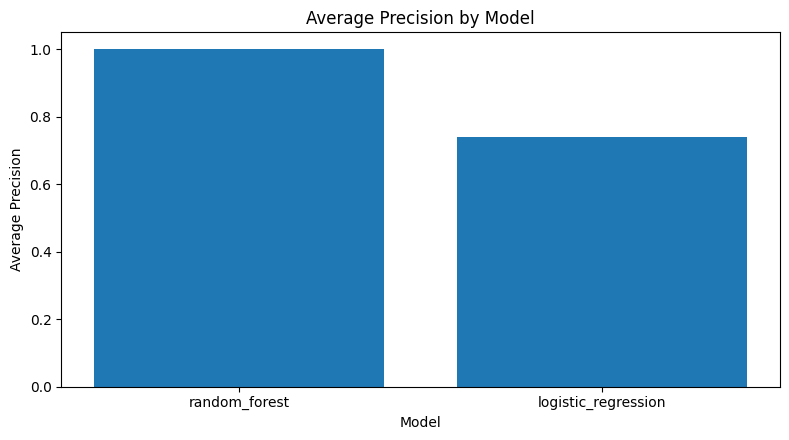

In [11]:
metrics = model_outputs["model_metrics"].copy()

plt.figure(figsize=(8, 4.5))
plt.bar(metrics["model"], metrics["average_precision"])
plt.title("Average Precision by Model")
plt.xlabel("Model")
plt.ylabel("Average Precision")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 12. Saving the modeling outputs

These modeling tables are saved to disk so they can be reused in the final business summary and in any later portfolio presentation materials.

Persisting the outputs also creates a clean handoff point between technical modeling work and stakeholder-facing communication.


In [12]:
for name, table in model_outputs.items():
    table.to_csv(OUTPUT_DIR / f"{name}.csv", index=False)

print("Saved modeling outputs to:", OUTPUT_DIR)


Saved modeling outputs to: /Users/twon/Documents/Time Series Analysis Project/data/outputs/phase_6_modeling


## 13. Phase summary

This notebook tested a time-aware supervised fraud-detection workflow on the engineered PaySim feature set.

The most important outcome is not simply that a model was trained. The key result is that the project now has a direct predictive layer built on top of the earlier monitoring and feature-engineering work. That creates a full analytical chain from raw data audit to EDA, behavioral feature design, anomaly scoring, and supervised fraud prediction.

The next notebook translates those technical results into a business-ready story for stakeholders who care less about implementation detail and more about what the project found, why it matters, and what should happen next.
